## Homework 4 Problems

In [2153]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np

#### Problem 1

In [2154]:
datasite='http://burro.case.edu/Academics/Astr222/HW/HW4/'
datafile='TF.dat'

In [2155]:
tf_dataset=ascii.read(datasite+datafile,header_start=-2,data_start=0)
print(tf_dataset.colnames)

['ngc', 'mB', 'mR', 'mI', 'inc', 'Vc_obs']


In [2156]:
ngc = tf_dataset['ngc']
mB = tf_dataset['mB']
mR = tf_dataset['mR']
mI = tf_dataset['mI']
inc = tf_dataset['inc']
Vc = tf_dataset['Vc_obs']

In [2157]:
Vtrue = Vc/ np.sin(np.deg2rad(inc))

In [2158]:
# make a linear fit using np.polyfit, and calculate uncertainty and scatter

def plots(m, title, color):
    coeff,cov=np.polyfit(np.log10(Vtrue/300),m,1,cov=True)
    coeff_err = np.sqrt(np.diag(cov))
    print('    slope = {:.3f} +/- {:.3f}'.format(coeff[0],coeff_err[0]))
    print('intercept = {:.3f} +/- {:.3f}'.format(coeff[1],coeff_err[1]))
    polynomial=np.poly1d(coeff)
    print('  scatter = {:.3f}'.format(np.std(m-polynomial(np.log10(Vtrue/300)))))
    # plot the data
    plt.ylabel('Apparent Magnitudes')
    plt.xlabel('log(v_true/300)')
    plt.title(f"The Tully-Fisher Plot for the {title} Band")
    plt.gca().invert_yaxis()

    # overplot your fit
    xfit=np.linspace(-.8,.1,100)
    plt.plot(xfit,polynomial(xfit),color= color,lw=2, alpha = .7, label = f'Tully Fisher fit to {title}')
    plt.scatter(np.log10(Vtrue/300),m, s = 15, color = 'black', alpha = .6, label = "Magnitude")
    plt.legend()

    slope = -7.388 +/- 0.614
intercept = 10.122 +/- 0.190
  scatter = 0.614


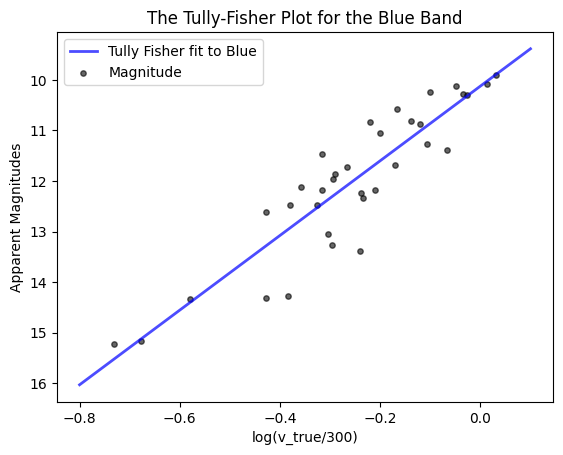

In [2159]:
plots(mB,'Blue', 'blue')

    slope = -8.721 +/- 0.635
intercept = 8.233 +/- 0.197
  scatter = 0.636


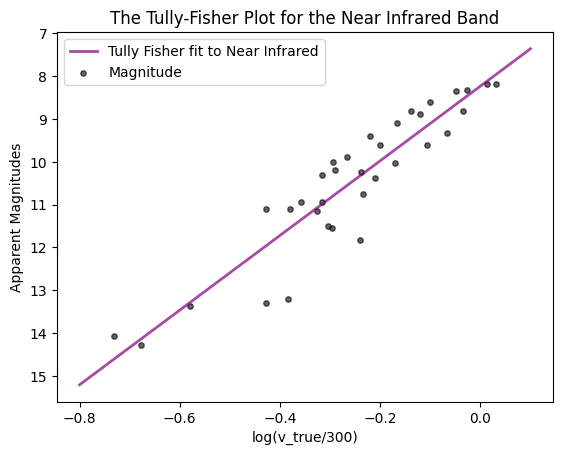

In [2160]:
plots(mI, "Near Infrared", 'purple')

    slope = -8.346 +/- 0.617
intercept = 8.817 +/- 0.191
  scatter = 0.618


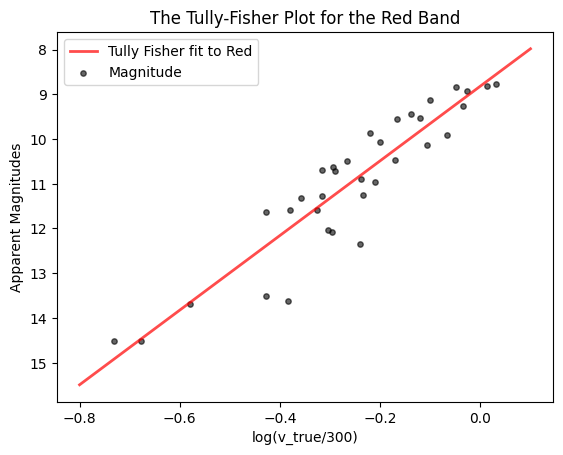

In [2161]:
plots(mR, "Red", 'red')

In [2162]:
m = [25.0, 25.4, 25.4, 25.6, 26.6, 26.6, 26.6, 26.0, 26.2, 25.6, 26.4, 26.6]
p = [53.1, 50.0, 43.2, 39.5, 30.4, 30.1, 29.5, 26.2, 26.0, 24.4, 24.0, 22.0]

M = -2.43*np.log10(p) - 1.62

d = 10**((m-M+5)/5)
print(d)

[14534360.81196024 16970686.94188055 15806841.58882303 16593812.8803756
 23156694.25877314 23045350.45232466 22820938.45620343 16341594.41945796
 17851595.89170726 13130203.45449821 18827066.79784246 19788707.2130971 ]


In [2163]:
print("{:.2E}".format(np.mean(d)))

1.82E+07


In [2164]:
print("{:.2E}".format(np.std(d)))

np.std(d)

3.23E+06


np.float64(3225307.908545829)

In [2165]:
m100_d = np.mean(d)
unc_m100_d = np.std(d)

m100_m_M = m-M
unc_m100_m_M = np.std(m100_m_M)

MB = -5*np.log10(m100_d)+5+mB
MR = -5*np.log10(m100_d)+5+mR
MI = -5*np.log10(m100_d)+5+mI

In [2166]:
def virgo_plot(Mag, title, color):
    coeff,cov=np.polyfit(np.log10(Vtrue/300),Mag,1,cov=True)
    coeff_err = np.sqrt(np.diag(cov))
    print('    slope = {:.3f} +/- {:.3f}'.format(coeff[0],coeff_err[0]))
    print('intercept = {:.3f} +/- {:.3f}'.format(coeff[1],coeff_err[1]))
    polynomial=np.poly1d(coeff)
    print('  scatter = {:.3f}'.format(np.std(Mag-polynomial(np.log10(Vtrue/300)))))
    #plotting the data and the fit
    plt.scatter(np.log10(Vtrue/300), Mag, c='k', label = 'Points', alpha = 0.7)
    #flip y axis to have brighter be up
    plt.gca().invert_yaxis()

    b_tf_xfit_M=np.linspace(np.min( np.log10(Vtrue/300)),np.max(np.log10(Vtrue/300)),100)
    plt.plot(b_tf_xfit_M, polynomial(b_tf_xfit_M), c=color, label='Linear Fit (T-F Relationship)', lw = 3)

    #UNCERTAINTY IN b: HAVE TO ADD IN QUADRATURE THE UNCERTAINTY OF THE FIT W THE UNCERAINTY IN m100_m_M
    b_unc_b_M = np.sqrt((coeff_err[1]**2)+(unc_m100_m_M**2))
    print('the uncertainty in b is:', b_unc_b_M)

    plt.xlabel(r'Rotation Speed, $\log(\frac{V_c}{300 km/s})$')
    plt.ylabel('Absolute Magnitude')
    plt.title('T-F Plot from Sprial Galaxies in the Virgo Cluster w/ Absolute Magnitudes ({}-Band)'.format(title))
    plt.legend()

    slope = -7.388 +/- 0.614
intercept = -21.183 +/- 0.190
  scatter = 0.614
the uncertainty in b is: 0.42763373583190634


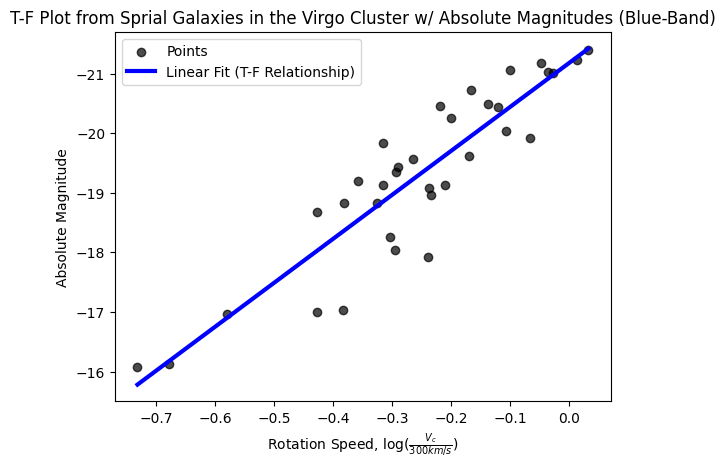

In [2167]:
virgo_plot(MB,'Blue', 'blue')

    slope = -8.721 +/- 0.635
intercept = -23.072 +/- 0.197
  scatter = 0.636
the uncertainty in b is: 0.43068442154814085


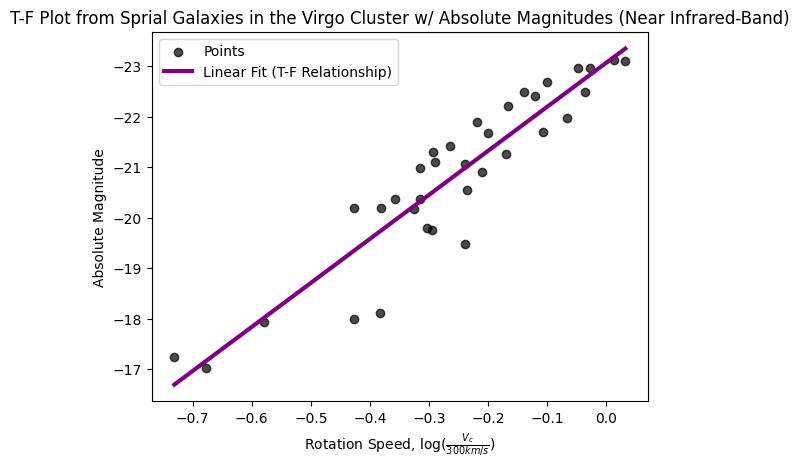

In [2168]:
virgo_plot(MI, "Near Infrared", 'purple')

    slope = -8.346 +/- 0.617
intercept = -22.488 +/- 0.191
  scatter = 0.618
the uncertainty in b is: 0.42817624625196915


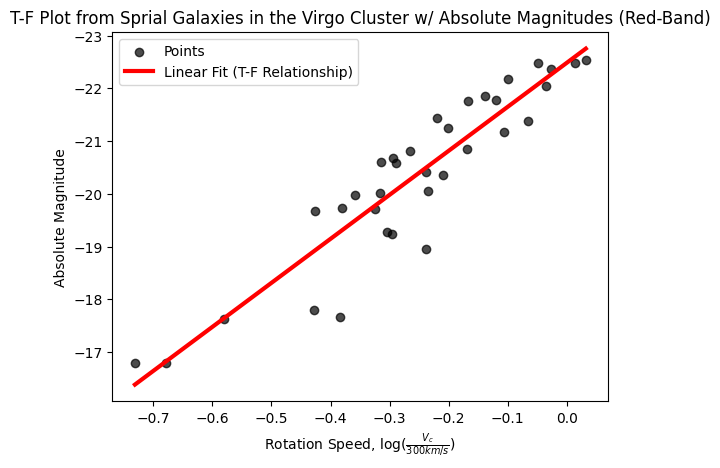

In [2169]:
virgo_plot(MR, "Red", 'red')

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
C:\Users\bhoom\AppData\Local\Temp\ipykernel_30124\3736983431.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(i_tf_xfit_M, i_tf_polynomial_M(i_tf_xfit_M), c='crimson', label='Linear Fit (T-F Relationship): \n a = -8.721 $\pm$ 0.635 \n b = -23.066 $\pm$ 0.447 \n scatter = 0.636')


    slope = -8.721 +/- 0.635
intercept = -23.072 +/- 0.197
  scatter = 0.636
the uncertainty in b is: 0.43068442154814085


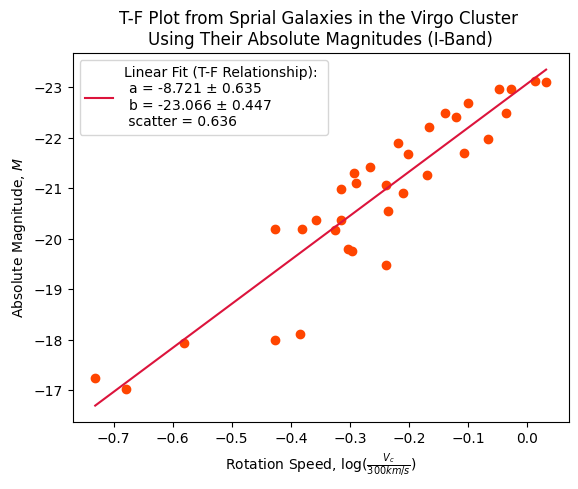

In [2170]:
i_tf_x = np.log10(Vtrue/300)

i_tf_coeff_M, i_tf_cov_M = np.polyfit(i_tf_x, MI, 1, cov=True)
i_tf_coeff_err_M = np.sqrt(np.diag(i_tf_cov_M))
print('    slope = {:.3f} +/- {:.3f}'.format(i_tf_coeff_M[0],i_tf_coeff_err_M[0]))
print('intercept = {:.3f} +/- {:.3f}'.format(i_tf_coeff_M[1],i_tf_coeff_err_M[1]))
i_tf_polynomial_M=np.poly1d(i_tf_coeff_M)
print('  scatter = {:.3f}'.format(np.std(MI-i_tf_polynomial_M(i_tf_x))))

#plotting the data and the fit
plt.scatter(i_tf_x, MI, c='orangered')
#flip y axis to have brighter be up
plt.gca().invert_yaxis()

i_tf_xfit_M=np.linspace(np.min(i_tf_x),np.max(i_tf_x),100)
plt.plot(i_tf_xfit_M, i_tf_polynomial_M(i_tf_xfit_M), c='crimson', label='Linear Fit (T-F Relationship): \n a = -8.721 $\pm$ 0.635 \n b = -23.066 $\pm$ 0.447 \n scatter = 0.636')

#UNCERTAINTY IN b: HAVE TO ADD IN QUADRATURE THE UNCERTAINTY OF THE FIT W THE UNCERAINTY IN m100_m_M
i_unc_b_M = np.sqrt((i_tf_coeff_err_M[1]**2)+(unc_m100_m_M**2))
print('the uncertainty in b is:', i_unc_b_M)

plt.xlabel(r'Rotation Speed, $\log(\frac{V_c}{300 km/s})$')
plt.ylabel(r'Absolute Magnitude, $M$')
plt.title('T-F Plot from Sprial Galaxies in the Virgo Cluster \nUsing Their Absolute Magnitudes (I-Band)')
plt.legend()

plt.savefig('ASTR222-HW4-TF-AbsMag-I.png', format="png", dpi=600)

In [2188]:
#spiral galaxy in the coma cluster
m_I_coma = 13.5

#M = alog(v/300)+b is a generalized eq, you have a and b for the I-band, and he gives you V of this galaxy
Vc_obs_coma = 180
inc_coma = 65
Vc_coma = Vc_obs_coma/np.sin(np.deg2rad(inc_coma))

#find abs mag (using a and b from the I-band)
M_coma = i_tf_coeff_M[0]*np.log10(Vc_coma/300)+i_tf_coeff_M[1]

#uncertainty in abs mag
M_coma_unc = np.sqrt((i_tf_coeff_err_M[0]**2)+(i_unc_b_M**2))

#work out distance using the distance modulus
coma_dist=10**((m_I_coma-M_coma+5)/5) #pc

#work out uncertainty in distance
#rel uncertainty is half the mag uncertainty (we're not given an unc for m so this is just the unc in M)
coma_rel_unc = M_coma_unc/2

#to get actual uncertainty, multiply by d
coma_actual_unc = coma_rel_unc*coma_dist #pc #damn thats big

print("Mag I: {}, Uncertainty: {}".format(M_coma, M_coma_unc))

print("Coma Distance: {:.3E}, Coma Uncertainty: {:.3E}".format(coma_dist, coma_actual_unc))

print("Coma Relative Uncertainty: {}".format(coma_rel_unc))

Mag I: -21.5096864506625, Uncertainty: 0.7675520042200288
Coma Distance: 1.004E+08, Coma Uncertainty: 3.855E+07
Coma Relative Uncertainty: 0.3837760021100144


#### Problem 3

In [2172]:
datafile='coma.dat'

In [2173]:
coma_dataset=ascii.read(datasite+datafile,header_start=-2,data_start=0)
print(coma_dataset.colnames)

['name', 'x', 'y', 'cz', 'Bt']


In [2174]:
cz_fixed = (coma_dataset['cz'] != 0)

coma_dataset = coma_dataset[cz_fixed]

In [2175]:
name = coma_dataset['name']
x = coma_dataset['x']
y = coma_dataset['y']
cz = coma_dataset['cz']
bt = coma_dataset['Bt']

Text(0.5, 1.0, 'X and Y Angular position relative to the Central Coma Cluster in Arcminutes')

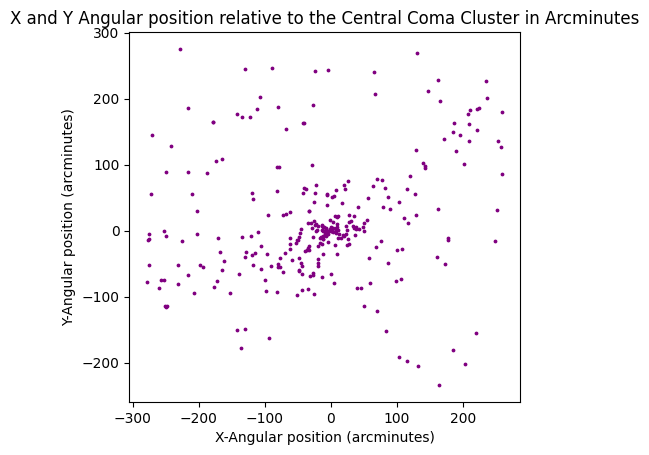

In [2176]:
fig, ax = plt.subplots()
plt.scatter(x,y, s = 3, color = 'purple')

ax.set_aspect('equal')
ax.set_xlabel("X-Angular position (arcminutes)")
ax.set_ylabel("Y-Angular position (arcminutes)")
ax.set_title("X and Y Angular position relative to the Central Coma Cluster in Arcminutes")

Text(0.5, 1.0, 'Histogram of Radial Velocity (km/s) of all Galaxies')

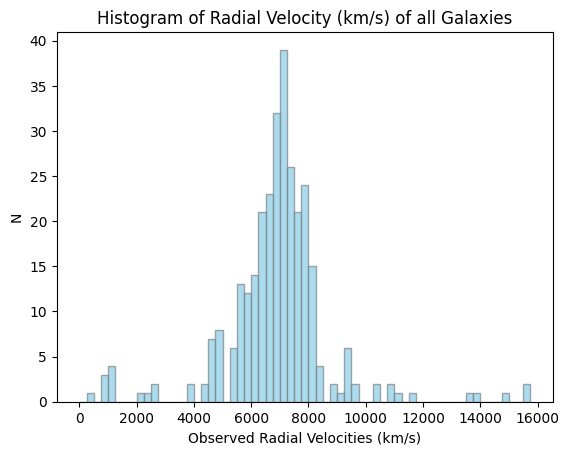

In [2177]:
fig, ax = plt.subplots()

vbins=np.arange(0,16000,250)
plt.hist(cz, bins=vbins, color='skyblue', edgecolor='grey', alpha=0.7)
plt.xlabel('Observed Radial Velocities (km/s)')
plt.ylabel('N')
plt.title('Histogram of Radial Velocity (km/s) of all Galaxies')

Mean: 6922.66
Standard Deviation: 1008.16


Text(0.5, 1.0, 'Histogram of Radial Velocity (km/s) of Galaxies with V between 4000 and 10000 km/sec')

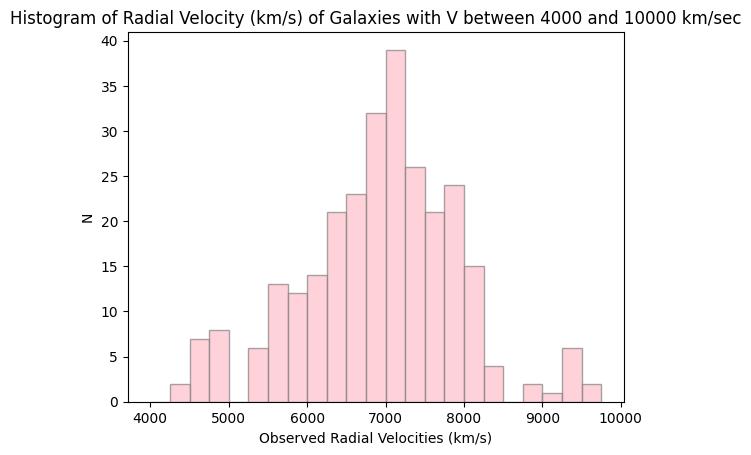

In [2178]:
fig, ax = plt.subplots()

vbins=np.arange(4000,10000,250)

counts, bin_edges = np.histogram(cz, bins=vbins)
bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

total_count = np.sum(counts)
mean = np.sum(bin_midpoints * counts) / np.sum(counts)
std = np.sqrt(np.sum(counts * (bin_midpoints - mean)**2) / total_count)
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")

plt.hist(cz, bins=vbins, color='pink', edgecolor='grey', alpha=0.7)
plt.xlabel('Observed Radial Velocities (km/s)')
plt.ylabel('N')
plt.title('Histogram of Radial Velocity (km/s) of Galaxies with V between 4000 and 10000 km/sec')

In [2179]:
subspace = (bt > 13) & (cz > 4907) & (cz < 8939)

In [2180]:
coma_sub = coma_dataset[subspace]
print(coma_sub)

name   x       y      cz     Bt 
---- ------ ------- ------ -----
   6 -270.7   145.5 7019.0 15.23
   8 -277.1  -14.33 8041.0 15.45
   9 -278.7  -78.25 6536.0 15.48
  10 -275.4   -4.41 6574.0 15.68
  11 -272.6   55.32 7321.0 15.13
  12 -275.5  -12.52 6699.0 15.12
  14 -275.3  -52.78 6987.0 14.98
  19 -260.9  -87.37 6559.0 15.34
  23 -253.1 -0.0583 7885.0 15.54
  25 -249.3  -7.763 7737.0 15.32
 ...    ...     ...    ...   ...
 405  195.1   144.7 6936.0 15.37
 407  202.2   101.0 6746.0 14.19
 410  207.8   177.4 5600.0 13.69
 413  210.1   161.1 5661.0 14.93
 414  210.9   182.3 5823.0 14.23
 420  222.3   183.9 5581.0 15.47
 421  224.2   185.9 5568.0 13.84
 434  251.3   30.76 6630.0 13.97
 438  257.9   127.5 7021.0 15.04
 442  259.7   179.6 7158.0 14.94
Length = 252 rows


In [2181]:
ss_d = np.sqrt(coma_sub['x']**2 + coma_sub['y']**2)
coma_sub['Distance'] = ss_d

In [2182]:
print(ss_d)

        x         
------------------
307.32513727321424
 277.4702847153187
 289.4766873169582
 275.4353065603609
 278.1565429753541
 275.7843367560964
280.31378560463276
 275.1405584424077
253.10000671451988
249.42083747954982
               ...
242.90347877294798
226.02176886308982
273.22444985762166
 264.7550188381705
278.76890070450827
 288.5073655905513
 291.2463733679786
 253.1755667516121
 287.6954292302886
 315.7534639556627
Length = 252 rows


In [2183]:
dist_coma = 99 * 1e6

ss_abs_mag = -5*np.log10(dist_coma)+5+coma_sub['Bt']

ss_lum = 10**(-0.4*ss_abs_mag + 2.2)

ss_lum_total = np.sum(ss_lum)
print(np.sum(ss_lum))

4420854132919.844


In [2184]:
half_light = coma_sub[(ss_d < 85)]


hl_abs_bmag = -5 * np.log10(dist_coma) + 5 + half_light['Bt']

hlums = 10**(-0.4 * hl_abs_bmag + 2.2)

hl_lum_total = np.sum(hlums)

print('goal:{:.2E}'.format(ss_lum_total / 2))
print("{:.2E}".format(hl_lum_total))

hl_rad_arcsec = 85*60
hl_rad_MPC = (hl_rad_arcsec * dist_coma) / 206265
hl_rad_pc = hl_rad_MPC

print("{:.2E}".format(hl_rad_MPC))

goal:2.21E+12
2.20E+12
2.45E+06


In [2185]:
G = 4.3e-3 #pc (km/s)^2 / M_0
mass_coma = (5*hl_rad_pc*(1008**2))/G


print("{:.2E}".format(mass_coma))
mass_coma

2.89E+15


2892027661413208.0

In [2186]:
3e13/ss_lum_total

np.float64(6.786018967829161)

In [2187]:
#bullet point 1
mass_3_star = 3 * 3e13 #L_0 #star mass

#bullet point 2
mass_20_total = 20 * 3e13 #L_0 # total mass

#bullet point 3
mass_hot_gas = 3e14
mass_dm = mass_coma - mass_20_total - mass_hot_gas #mass_coma is from that equation earlier
dm_percent = mass_dm/mass_coma
dm_percent #yeah shes correct

dm_percent

print(dm_percent)

0.6887996570682144
